# 🖥️ Reto de nivel Python — TecnoStore (SOLUCIÓN)

**Datogami · Evaluación de nivel**

> ⚠️ Este es el notebook de **solución**. Contiene una propuesta de resolución
> comentada. No hay una única respuesta correcta: lo importante es el criterio.

## 🎬 Contexto

Trabajas como analista de datos en **TecnoStore**, una empresa de venta de
ordenadores y componentes. El equipo de sistemas te pasa el inventario en
bruto (`inventario_tecnostore.csv`) y te pide tres cosas:

1. **Limpiar** los datos (vienen sucios de verdad).
2. Sacar unas **estadísticas** de negocio.
3. Preparar unas **visualizaciones** para la reunión.

El reto va de **más fácil a más difícil**. ¡Vamos!

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

---
# PARTE 0 · Carga y primera exploración

Antes de tocar nada, **mira** los datos. Nunca limpies a ciegas.

In [2]:
df = pd.read_csv("inventario_tecnostore.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (232, 12)


,id_producto,modelo,categoria,marca,coste_eur,precio_eur,stock,unidades_vendidas,valoracion,garantia_meses,fecha_alta,descatalogado
0,P0038,MSI SOB-395,Sobremesa,MSI,1083.04,"1542,57 €",39,117,NaN,12.0,2024-06-21,0
1,P0055,MSI SOB-497,Sobremesa,MSI,1430.34,"1727,93",29,473,3.3,24.0,2022-04-18,no
2,P0145,Logitech PER-517,Periférico,Logitech,16189.00,"216,61",99,238,4.8,24.0,2019-06-16,no
3,P0064,MSI SOB-990,Sobremesa,MSI,694.75,"845,07 €",63,208,5.0,36.0,2020-11-22,No
4,P0120,Samsung MON-504,monitor,Samsung,669.54,"861,76",56,277,4.2,12.0,2022-01-27,no


In [3]:
# .info() nos dice tipos y nulos por columna. Fíjate en las columnas 'object':
# suelen esconder texto donde debería haber números.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_producto        232 non-null    str    
 1   modelo             232 non-null    str    
 2   categoria          232 non-null    str    
 3   marca              232 non-null    str    
 4   coste_eur          232 non-null    float64
 5   precio_eur         232 non-null    str    
 6   stock              224 non-null    str    
 7   unidades_vendidas  232 non-null    int64  
 8   valoracion         205 non-null    float64
 9   garantia_meses     219 non-null    float64
 10  fecha_alta         232 non-null    str    
 11  descatalogado      232 non-null    str    
dtypes: float64(3), int64(1), str(8)
memory usage: 21.9 KB


In [4]:
# describe(include="all") da un resumen de TODAS las columnas, no solo numéricas.
df.describe(include="all")

,id_producto,modelo,categoria,marca,coste_eur,precio_eur,stock,unidades_vendidas,valoracion,garantia_meses,fecha_alta,descatalogado
count,232,232,232,232,232.000000,232,224,232.000000,205.000000,219.000000,232,232
unique,220,220,21,33,NaN,220,109,NaN,NaN,NaN,211,8
top,P0064,MSI SOB-990,COMPONENTE,Dell,NaN,"845,07 €",63,NaN,NaN,NaN,2021-02-16,no
freq,2,2,21,28,NaN,2,5,NaN,NaN,NaN,3,55
mean,NaN,NaN,NaN,NaN,2149.899698,NaN,NaN,248.939655,4.059512,24.164384,NaN,NaN
std,NaN,NaN,NaN,NaN,8743.355115,NaN,NaN,149.802484,4.516568,10.051720,NaN,NaN
min,NaN,NaN,NaN,NaN,23.270000,NaN,NaN,2.000000,-3.900000,12.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,293.790000,NaN,NaN,110.000000,3.100000,12.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,676.590000,NaN,NaN,264.500000,3.700000,24.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,1316.857500,NaN,NaN,379.000000,4.400000,36.000000,NaN,NaN


### 🔎 Diagnóstico
Con lo anterior detectamos: `precio_eur`, `stock`, `garantia_meses` y
`descatalogado` son texto (`object`) cuando no deberían; hay nulos; y
seguramente valores raros. Vamos parte por parte.

---
# PARTE 1 · Limpieza (de fácil a difícil)

## 1.1 · Duplicados

**Teoría:** un duplicado exacto es una fila repetida al 100%. Distorsiona
cualquier conteo o media. `duplicated()` los marca y `drop_duplicates()` los
elimina.

In [5]:
print("Duplicados exactos:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Filas tras eliminar duplicados:", len(df))

Duplicados exactos: 12
Filas tras eliminar duplicados: 220


## 1.2 · Normalizar texto (categorías y marcas)

**Teoría:** `"Portátil"`, `" portatil "` y `"PORTÁTIL"` son *la misma
categoría* para un humano, pero tres valores distintos para Python. Hay que
**unificar**: quitar espacios (`str.strip`), homogeneizar mayúsculas y mapear
a un valor canónico.

In [6]:
import unicodedata

def normaliza(texto):
    """minúsculas, sin espacios extra y sin acentos -> para comparar."""
    t = str(texto).strip().lower()
    t = "".join(c for c in unicodedata.normalize("NFKD", t)
                if not unicodedata.combining(c))
    return t

# Mapa: forma normalizada -> nombre canónico bonito
mapa_categorias = {
    "portatil":   "Portátil",
    "sobremesa":  "Sobremesa",
    "monitor":    "Monitor",
    "periferico": "Periférico",
    "componente": "Componente",
}
df["categoria"] = df["categoria"].apply(normaliza).map(mapa_categorias)
df["marca"] = df["marca"].str.strip()

print(df["categoria"].value_counts())
print("\nMarcas:", sorted(df["marca"].unique()))

categoria
Portátil      58
Componente    51
Sobremesa     39
Monitor       37
Periférico    35
Name: count, dtype: int64

Marcas: ['AMD', 'Acer', 'Apple', 'Asus', 'BenQ', 'Corsair', 'Dell', 'HP', 'Intel', 'Kingston', 'LG', 'Lenovo', 'Logitech', 'MSI', 'Microsoft', 'Nvidia', 'Razer', 'Samsung']


## 1.3 · Convertir `precio_eur` de texto a número

**Teoría:** el precio viene como `"1.542,57 €"`: con símbolo de euro, espacios
y **coma** como separador decimal. Para convertirlo a `float` hay que limpiar
el string: quitar `€` y espacios, y cambiar la coma por punto.

In [7]:
def limpia_precio(valor):
    s = str(valor).replace("€", "").replace(" ", "").strip()
    s = s.replace(",", ".")
    return float(s)

df["precio_eur"] = df["precio_eur"].apply(limpia_precio)
print(df["precio_eur"].describe())

count     220.000000
mean      990.793227
std       785.862282
min        29.950000
25%       274.325000
50%       842.155000
75%      1513.730000
max      3212.910000
Name: precio_eur, dtype: float64


## 1.4 · Convertir `stock` y `garantia_meses` a numérico

**Teoría:** `stock` mezcla números con textos como `"desconocido"`, `"N/A"`,
`"-"` o vacíos. `pd.to_numeric(..., errors="coerce")` convierte lo que puede a
número y pone `NaN` en lo que no puede. Así aislamos los missings reales.

In [8]:
df["stock"] = pd.to_numeric(df["stock"], errors="coerce")
df["garantia_meses"] = pd.to_numeric(df["garantia_meses"], errors="coerce")
print("Nulos en stock:", df["stock"].isna().sum())
print("Nulos en garantia_meses:", df["garantia_meses"].isna().sum())

Nulos en stock: 15
Nulos en garantia_meses: 12


## 1.5 · Gestionar errores y valores imposibles

**Teoría:** no todo error es un nulo. A veces el dato *existe* pero es
**imposible** según las reglas de negocio. Hay que detectarlos con criterio:

- **Stock negativo** → no existe stock negativo. Lo tratamos como error → `NaN`.
- **Valoración fuera de [0, 5]** → la escala es de 0 a 5. Fuera de ahí → `NaN`.
- **Coste > precio de venta** → venderíamos a pérdida; es un error de tecleo
  (un cero de más). Lo corregimos dividiendo entre 100.

In [9]:
# Stock negativo -> NaN
df.loc[df["stock"] < 0, "stock"] = np.nan

# Valoración fuera de rango -> NaN
df.loc[(df["valoracion"] < 0) | (df["valoracion"] > 5), "valoracion"] = np.nan

# Coste imposible (mayor que el PVP) -> error x100, lo corregimos
mask_error_coste = df["coste_eur"] > df["precio_eur"]
print("Costes imposibles detectados:", mask_error_coste.sum())
df.loc[mask_error_coste, "coste_eur"] = df.loc[mask_error_coste, "coste_eur"] / 100

Costes imposibles detectados: 10


## 1.6 · Imputar los missings

**Teoría:** una vez aislados los nulos, decidimos qué hacer. Eliminar filas
no siempre es buena idea (perdemos información). Aquí **imputamos**:

- `valoracion` → mediana **por categoría** (más justo que una global).
- `stock` → mediana global (redondeada a entero).
- `garantia_meses` → la moda (el valor más frecuente).

In [10]:
df["valoracion"] = df["valoracion"].fillna(
    df.groupby("categoria")["valoracion"].transform("median")
)
df["stock"] = df["stock"].fillna(df["stock"].median()).round().astype(int)
df["garantia_meses"] = df["garantia_meses"].fillna(
    df["garantia_meses"].mode()[0]
).astype(int)

print("Nulos restantes por columna:")
print(df.isna().sum())

Nulos restantes por columna:
id_producto          0
modelo               0
categoria            0
marca                0
coste_eur            0
precio_eur           0
stock                0
unidades_vendidas    0
valoracion           0
garantia_meses       0
fecha_alta           0
descatalogado        0
dtype: int64


## 1.7 · Normalizar `descatalogado` a booleano y FILTRAR

**Teoría:** `descatalogado` viene como `"Sí"`, `"SI"`, `"true"`, `"1"`,
`"No"`, `"false"`... Lo convertimos a `True/False` real y **filtramos**: un
producto descatalogado ya no se vende, así que fuera del análisis.

In [11]:
valores_true = {"sí", "si", "true", "1"}
df["descatalogado"] = df["descatalogado"].apply(
    lambda v: normaliza(v) in valores_true
)
print("Descatalogados a eliminar:", df["descatalogado"].sum())

df = df[~df["descatalogado"]].reset_index(drop=True)
df = df.drop(columns="descatalogado")   # ya no aporta: todos son False
print("Filas finales (catálogo activo):", len(df))

Descatalogados a eliminar: 31
Filas finales (catálogo activo): 189


## 1.8 · Tipos finales (fecha)

**Teoría:** `fecha_alta` es texto. La convertimos a `datetime` para poder
operar con fechas (año, antigüedad, etc.).

In [12]:
df["fecha_alta"] = pd.to_datetime(df["fecha_alta"], errors="coerce")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_producto        189 non-null    str           
 1   modelo             189 non-null    str           
 2   categoria          189 non-null    str           
 3   marca              189 non-null    str           
 4   coste_eur          189 non-null    float64       
 5   precio_eur         189 non-null    float64       
 6   stock              189 non-null    int64         
 7   unidades_vendidas  189 non-null    int64         
 8   valoracion         189 non-null    float64       
 9   garantia_meses     189 non-null    int64         
 10  fecha_alta         189 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(3), str(4)
memory usage: 16.4 KB


✅ **Base de datos limpia.** Sin duplicados, tipos correctos, sin nulos,
categorías unificadas y solo catálogo activo. Ahora sí, a analizar.

---
# PARTE 2 · Estadísticas de negocio

## 2.1 · Resumen numérico general

In [13]:
df.describe()

,coste_eur,precio_eur,stock,unidades_vendidas,valoracion,garantia_meses,fecha_alta
count,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189
mean,704.881852,957.228571,59.328042,237.714286,3.739418,24.825397,2021-10-31 11:25:42.857142
min,23.270000,29.950000,0.000000,6.000000,2.500000,12.000000,2019-01-08 00:00:00
25%,194.750000,246.650000,36.000000,98.000000,3.300000,12.000000,2020-08-09 00:00:00
50%,595.440000,818.680000,56.000000,227.000000,3.700000,24.000000,2021-08-25 00:00:00
75%,1042.490000,1494.410000,89.000000,378.000000,4.200000,36.000000,2022-12-25 00:00:00
max,2085.120000,3212.910000,119.000000,499.000000,5.000000,36.000000,2024-12-20 00:00:00
std,553.445343,767.398019,32.717168,149.556411,0.682041,9.905736,NaN


## 2.2 · Métricas derivadas

**Teoría:** el valor no está solo en las columnas que te dan, sino en las que
**construyes**. Creamos:
- `margen_eur` = precio − coste
- `margen_pct` = margen / precio × 100
- `ingresos_eur` = precio × unidades vendidas

In [14]:
df["margen_eur"] = df["precio_eur"] - df["coste_eur"]
df["margen_pct"] = (df["margen_eur"] / df["precio_eur"] * 100).round(1)
df["ingresos_eur"] = (df["precio_eur"] * df["unidades_vendidas"]).round(2)
df[["modelo", "precio_eur", "coste_eur", "margen_eur", "margen_pct", "ingresos_eur"]].head()

,modelo,precio_eur,coste_eur,margen_eur,margen_pct,ingresos_eur
0,MSI SOB-395,1542.57,1083.04,459.53,29.8,180480.69
1,MSI SOB-497,1727.93,1430.34,297.59,17.2,817310.89
2,Logitech PER-517,216.61,161.89,54.72,25.3,51553.18
3,MSI SOB-990,845.07,694.75,150.32,17.8,175774.56
4,Samsung MON-504,861.76,669.54,192.22,22.3,238707.52


## 2.3 · Agregación por categoría

**Teoría:** `groupby` parte los datos por grupos y aplica una función a cada
uno. Con `.agg()` calculamos varias métricas de golpe.

In [15]:
resumen_cat = df.groupby("categoria").agg(
    n_productos=("id_producto", "count"),
    precio_medio=("precio_eur", "mean"),
    stock_total=("stock", "sum"),
    valoracion_media=("valoracion", "mean"),
    ingresos_totales=("ingresos_eur", "sum"),
).round(2).sort_values("ingresos_totales", ascending=False)
resumen_cat

,n_productos,precio_medio,stock_total,valoracion_media,ingresos_totales
categoria,,,,,
Portátil,51,1503.72,3203,3.72,15969828.99
Sobremesa,31,1860.91,1844,3.73,13102335.47
Componente,42,571.55,2189,3.60,6419641.55
Monitor,32,561.20,1891,3.83,4806072.51
Periférico,33,138.62,2086,3.86,1007518.04


## 2.4 · Rankings

In [16]:
# Top 10 productos por ingresos
top_ingresos = df.nlargest(10, "ingresos_eur")[
    ["modelo", "categoria", "precio_eur", "unidades_vendidas", "ingresos_eur"]
]
print("TOP 10 productos por ingresos:")
print(top_ingresos.to_string(index=False))

TOP 10 productos por ingresos:
        modelo categoria  precio_eur  unidades_vendidas  ingresos_eur
Lenovo SOB-941 Sobremesa     2344.69                476    1116072.44
Lenovo SOB-120 Sobremesa     2052.88                498    1022334.24
  Acer POR-906  Portátil     2060.10                462     951766.20
  Dell SOB-729 Sobremesa     1986.77                479     951662.83
    HP POR-684  Portátil     2062.30                448     923910.40
  Dell SOB-548 Sobremesa     2162.55                422     912596.10
 Apple POR-370  Portátil     2046.67                412     843228.04
Lenovo POR-943  Portátil     2165.45                387     838029.15
   MSI SOB-497 Sobremesa     1727.93                473     817310.89
  Asus SOB-760 Sobremesa     2705.70                265     717010.50


In [17]:
# Marca que más factura
por_marca = df.groupby("marca")["ingresos_eur"].sum().sort_values(ascending=False)
print("\nIngresos por marca:")
print(por_marca.round(2))


Ingresos por marca:
marca
Dell         7611716.30
Lenovo       6302555.84
HP           4102854.50
Apple        3810989.60
Intel        3490313.54
MSI          3421067.33
Asus         3005519.57
Acer         2472300.47
Samsung      1853984.65
Nvidia       1441872.94
BenQ          766925.59
Kingston      726752.21
LG            680600.00
AMD           562056.74
Razer         340665.66
Corsair       299932.53
Logitech      273640.71
Microsoft     141648.38
Name: ingresos_eur, dtype: float64


## 2.5 · Correlaciones

**Teoría:** la correlación mide si dos variables se mueven juntas (de −1 a 1).
Ojo: correlación **no** implica causalidad.

In [18]:
num_cols = ["coste_eur", "precio_eur", "stock", "unidades_vendidas",
            "valoracion", "margen_pct", "ingresos_eur"]
matriz_corr = df[num_cols].corr().round(2)
matriz_corr

,coste_eur,precio_eur,stock,unidades_vendidas,valoracion,margen_pct,ingresos_eur
coste_eur,1.00,0.99,0.03,-0.06,-0.08,0.07,0.67
precio_eur,0.99,1.00,0.03,-0.08,-0.07,0.19,0.64
stock,0.03,0.03,1.00,-0.06,-0.02,0.02,-0.03
unidades_vendidas,-0.06,-0.08,-0.06,1.00,-0.18,-0.07,0.55
valoracion,-0.08,-0.07,-0.02,-0.18,1.00,0.06,-0.12
margen_pct,0.07,0.19,0.02,-0.07,0.06,1.00,0.02
ingresos_eur,0.67,0.64,-0.03,0.55,-0.12,0.02,1.00


---
# PARTE 3 · Visualización (de fácil a difícil)

## 3.1 · Histograma: distribución de precios

**Teoría:** un histograma muestra cómo se reparten los valores de UNA variable
numérica. Útil para ver si hay concentración, sesgo o colas.

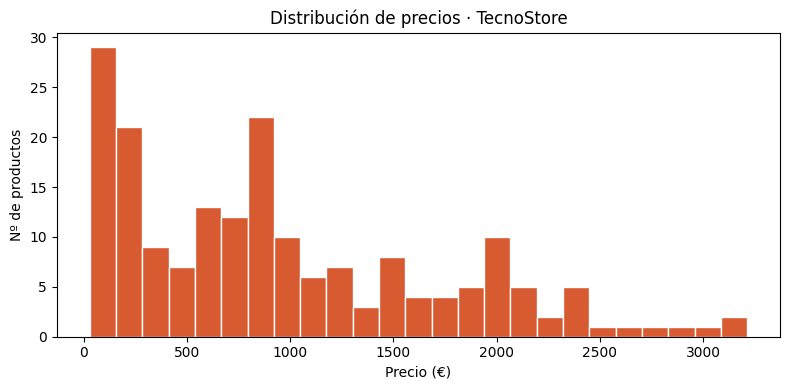

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(df["precio_eur"], bins=25, color="#D85A30", edgecolor="white")
plt.title("Distribución de precios · TecnoStore")
plt.xlabel("Precio (€)")
plt.ylabel("Nº de productos")
plt.tight_layout()
plt.show()

## 3.2 · Barras: precio medio por categoría

**Teoría:** el gráfico de barras compara una métrica entre categorías.

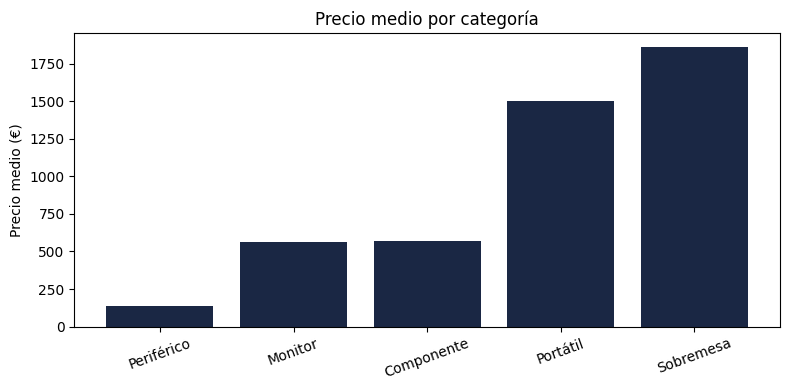

In [20]:
precio_cat = df.groupby("categoria")["precio_eur"].mean().sort_values()
plt.figure(figsize=(8, 4))
plt.bar(precio_cat.index, precio_cat.values, color="#1A2744")
plt.title("Precio medio por categoría")
plt.ylabel("Precio medio (€)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3.3 · Boxplot: dispersión del precio por categoría

**Teoría:** el boxplot resume mediana, cuartiles y outliers. Ideal para
comparar la *dispersión* entre grupos, no solo la media.

/tmp/ipykernel_668/1097216797.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_box, labels=categorias_orden)


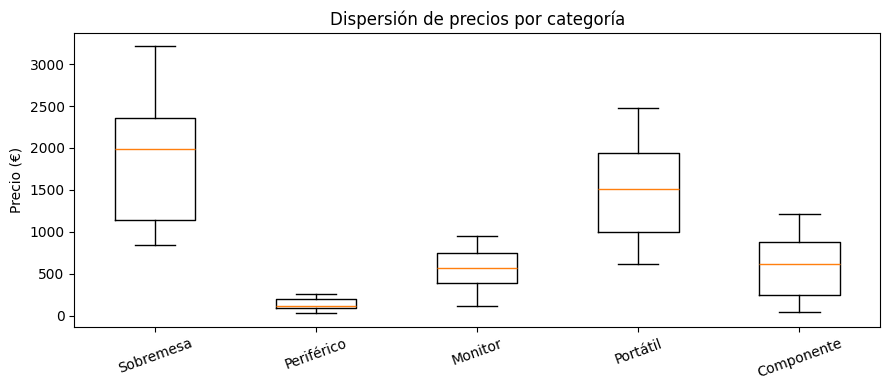

In [21]:
categorias_orden = df["categoria"].unique()
datos_box = [df.loc[df["categoria"] == c, "precio_eur"] for c in categorias_orden]
plt.figure(figsize=(9, 4))
plt.boxplot(datos_box, labels=categorias_orden)
plt.title("Dispersión de precios por categoría")
plt.ylabel("Precio (€)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3.4 · Scatter: ¿relación entre valoración y unidades vendidas?

**Teoría:** el scatter (dispersión) enfrenta DOS variables numéricas para ver
si hay relación. Coloreamos por categoría para añadir una tercera dimensión.

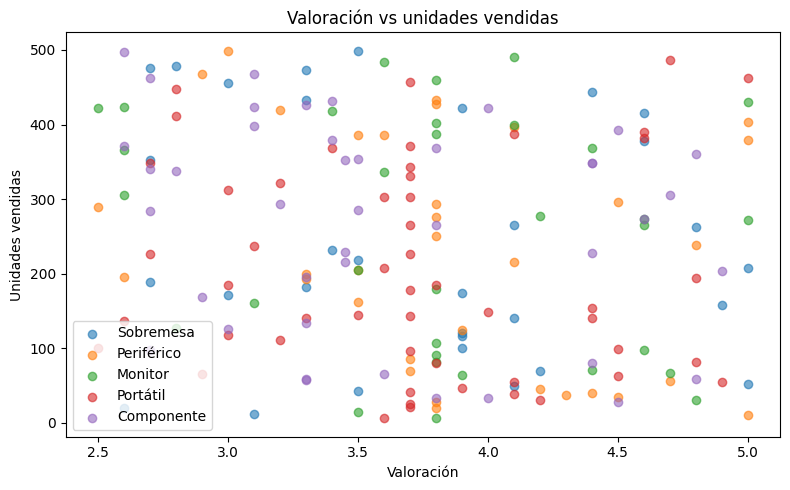

In [22]:
plt.figure(figsize=(8, 5))
for cat in df["categoria"].unique():
    sub = df[df["categoria"] == cat]
    plt.scatter(sub["valoracion"], sub["unidades_vendidas"], label=cat, alpha=0.6)
plt.title("Valoración vs unidades vendidas")
plt.xlabel("Valoración")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.tight_layout()
plt.show()

## 3.5 · Heatmap de correlaciones (nivel avanzado)

**Teoría:** un mapa de calor de la matriz de correlación permite ver de un
vistazo qué variables se relacionan. Lo hacemos solo con matplotlib
(sin seaborn) para que dependa de menos librerías.

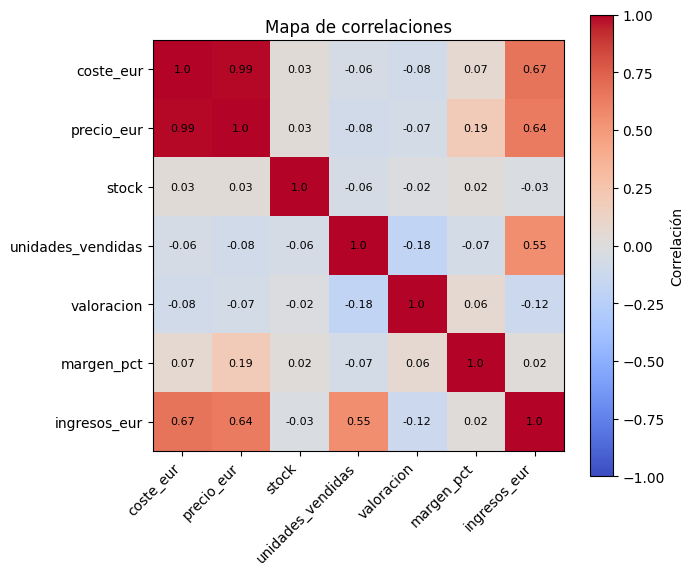

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)
# Anotamos el valor en cada celda
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, matriz_corr.iloc[i, j], ha="center", va="center",
                color="black", fontsize=8)
plt.colorbar(im, label="Correlación")
plt.title("Mapa de correlaciones")
plt.tight_layout()
plt.show()

## 3.6 · Reto final: ingresos por marca (barras horizontales ordenadas)

**Teoría:** combina agregación + orden + visualización. Las barras
horizontales van muy bien cuando hay muchas etiquetas o son largas.

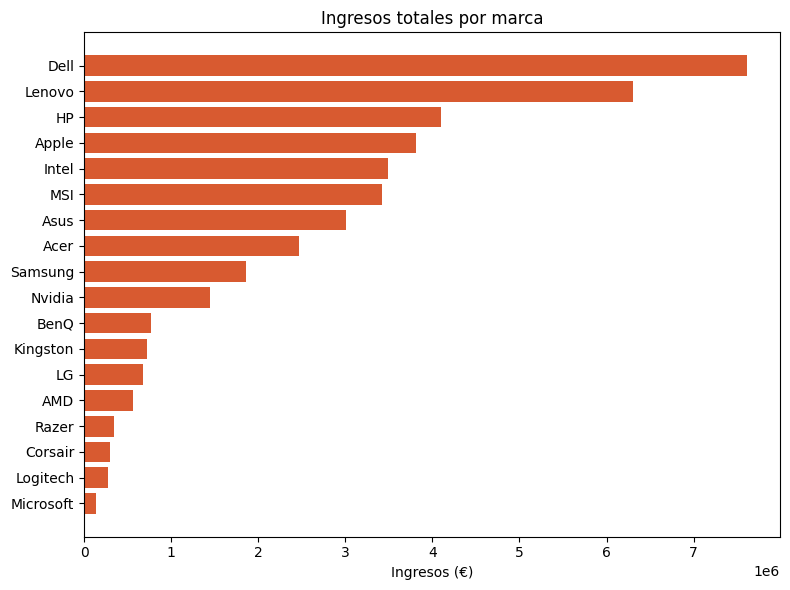

In [24]:
ing_marca = df.groupby("marca")["ingresos_eur"].sum().sort_values()
plt.figure(figsize=(8, 6))
plt.barh(ing_marca.index, ing_marca.values, color="#D85A30")
plt.title("Ingresos totales por marca")
plt.xlabel("Ingresos (€)")
plt.tight_layout()
plt.show()

---
## 🏁 Cierre

Has recorrido el flujo completo de un analista: **cargar → limpiar → analizar
→ visualizar**. En un caso real, la limpieza suele ser el 70–80% del trabajo.
Si has llegado hasta aquí con criterio propio, tu nivel de Python para datos
es más que sólido. 🚀